# Limit Hold'em — Algorithm Head-to-Head

Exploitability isn't tractable on Limit Hold'em (game tree is too large), so we measure relative skill via **head-to-head duplicate-poker matches**.

Three agents, all trained fresh here from the same budget for a fair comparison:

| Agent     | Params                                            |
|-----------|---------------------------------------------------|
| MCCFR     | baseline (`alpha=beta=gamma=inf`, `clip=False`)   |
| MCCFR+    | RM+ clipping only (`clip=True`)                   |
| DCFR      | `alpha=1.5, beta=0, gamma=2`                      |

All use `NUM_BUCKETS=15`. Variants train **concurrently** via `ProcessPoolExecutor`, so wall time is roughly the slowest variant rather than the sum.

Then we run a round-robin: each pair plays a large number of *duplicate* hands (same deal played twice with seats swapped) to slash card-luck variance.

Payoff unit: same as MCCFR's internal payoff — multiples of the ante (preflop bet = 2, postflop bet = 4).

In [1]:
import sys
sys.path.insert(0, '..')

import time
import random
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

from src.algorithms.mccfr import MCCFR
from src.training.limit_poker import LimitPokerRules

## Config

In [2]:
NUM_BUCKETS = 20
TRAIN_ITERATIONS = 500_000      # match the existing MCCFR-15 training budget
NUM_MATCH_PAIRS = 20_000        # duplicate pairs per pairing; each pair = 2 hands
MATCH_SEED = 42                 # seed for match RNG (action sampling + deals)
INF = float('inf')

LimitPokerRules.NUM_BUCKETS = NUM_BUCKETS
rules = LimitPokerRules()

#Train all three variants concurrently

Three independent `MCCFR` runs share nothing, so they parallelize cleanly across cores. We use a `fork` context — on macOS `spawn` would re-execute the notebook cells in each child, which doesn't work; `fork` inherits the parent's already-imported modules.

In [3]:
def _train_variant(name, alpha, beta, gamma, clip, iters, num_buckets):
    from src.algorithms.mccfr import MCCFR
    from src.training.limit_poker import LimitPokerRules
    LimitPokerRules.NUM_BUCKETS = num_buckets
    rules = LimitPokerRules()
    algo = MCCFR(rules, alpha=alpha, beta=beta, gamma=gamma, clip=clip)
    algo.train(iters)
    return name, algo.get_strategy(), len(algo.info_sets)


VARIANT_PARAMS = {
    'MCCFR':  dict(alpha=INF, beta=INF, gamma=INF, clip=False),
    'MCCFR+': dict(alpha=INF, beta=INF, gamma=INF, clip=True),
    'DCFR':   dict(alpha=1.5, beta=0.0, gamma=2.0, clip=False),
}

t0 = time.time()
ctx = mp.get_context('fork')
strategies = {}
info_set_counts = {}

with ProcessPoolExecutor(max_workers=len(VARIANT_PARAMS), mp_context=ctx) as ex:
    futures = {
        ex.submit(_train_variant, name, **params,
                  iters=TRAIN_ITERATIONS, num_buckets=NUM_BUCKETS): name
        for name, params in VARIANT_PARAMS.items()
    }
    for f in as_completed(futures):
        name, strat, n_info = f.result()
        strategies[name] = strat
        info_set_counts[name] = n_info
        print(f'  {name:<8} done — {n_info:>7,} info sets — {time.time() - t0:>6.0f}s elapsed')

print(f'\nTotal wall time: {time.time() - t0:.0f}s')

AGENTS = {name: strategies[name] for name in VARIANT_PARAMS}

  MCCFR    done — 163,626 info sets —   5776s elapsed
  DCFR     done — 163,823 info sets —   5828s elapsed
  MCCFR+   done — 163,845 info sets —   5855s elapsed

Total wall time: 5855s


In [4]:
import json
import os
from src.training.limit_poker import LimitPokerRules

os.makedirs("docs/models", exist_ok=True)

LimitPokerRules.NUM_BUCKETS = NUM_BUCKETS
rules = LimitPokerRules()

for name, strategy in AGENTS.items():
    export = {}

    for key, probs in strategy.items():
        history = key.split(":")[1]
        actions = rules.get_legal_actions(history)

        # Skip terminal states
        if len(actions) == 1 and actions[0] == "//":
            continue

        export[key] = {
            "actions": actions,
            "probs": [round(float(p), 6) for p in probs]
        }

    filename = f"docs/models/{name}.json"

    with open(filename, "w") as f:
        json.dump(export, f, indent=2)

    print(f"Exported {len(export):,} info sets -> {filename}")

Exported 163,626 info sets -> docs/models/MCCFR.json
Exported 163,845 info sets -> docs/models/MCCFR+.json
Exported 163,823 info sets -> docs/models/DCFR.json


## Head-to-head simulator (duplicate poker)

For each duplicate pair we draw one deal `(hole0, hole1, board)` and play it twice:

- **Game 1**: agent A sits as P0 with `hole0`, agent B sits as P1 with `hole1`.
- **Game 2**: same deal, agents swap seats — agent B sits as P0 with `hole0`, agent A sits as P1 with `hole1`.

A's net for the pair = (P0 payoff in game 1) − (P0 payoff in game 2). Card-luck cancels exactly when both agents play identically, so the residual measures skill.

In [5]:
def play_hand(rules, strats, hole_p0, hole_p1, board, rng):
    """Play one hand; return P0's payoff."""
    history = ''
    hole = (hole_p0, hole_p1)
    com = (board, None, None)
    while not rules.is_terminal(history):
        legal = rules.get_legal_actions(history)
        if len(legal) == 1 and legal[0] not in ('F', 'P', 'C', 'B', 'R'):
            history += legal[0]
            continue
        player = rules.get_acting_player(history)
        key = rules.get_info_set_string(hole[player], history, com)
        probs = strats[player].get(key)
        if probs is None or len(probs) != len(legal):
            probs = [1.0 / len(legal)] * len(legal)
        r = rng.random()
        cum = 0.0
        chosen = legal[-1]
        for a, p in zip(legal, probs):
            cum += p
            if r < cum:
                chosen = a
                break
        history += chosen
    return rules.get_payoff(hole, history, com)


def play_duplicate_match(rules, strat_a, strat_b, num_pairs, seed):
    """Run num_pairs duplicate pairs; return per-pair list of A's net payoff."""
    rng = random.Random(seed)
    nets = np.empty(num_pairs, dtype=np.float64)
    for i in range(num_pairs):
        cards = rng.sample(range(52), 9)
        hole0 = (cards[0], cards[1])
        hole1 = (cards[2], cards[3])
        board = (cards[4], cards[5], cards[6], cards[7], cards[8])
        # Game 1: A=P0, B=P1
        p0_payoff_1 = play_hand(rules, (strat_a, strat_b), hole0, hole1, board, rng)
        # Game 2: B=P0, A=P1 — A's payoff = -P0's payoff
        p0_payoff_2 = play_hand(rules, (strat_b, strat_a), hole0, hole1, board, rng)
        nets[i] = p0_payoff_1 - p0_payoff_2
    return nets

## Round-robin

Three agents → three pairings. Each pairing runs `NUM_MATCH_PAIRS` duplicate pairs.

In [6]:
results = {}
names = list(AGENTS.keys())
for a, b in combinations(names, 2):
    print(f'{a} vs {b}...')
    nets = play_duplicate_match(rules, AGENTS[a], AGENTS[b], NUM_MATCH_PAIRS, seed=MATCH_SEED)
    mean = nets.mean() / 2.0           # per hand (each pair is 2 hands)
    stderr = nets.std(ddof=1) / np.sqrt(len(nets)) / 2.0
    results[(a, b)] = {'mean': mean, 'stderr': stderr, 'nets': nets}
    print(f'  {a} net/hand vs {b}: {mean:+.4f} ± {1.96 * stderr:.4f} (95% CI)')

MCCFR vs MCCFR+...
  MCCFR net/hand vs MCCFR+: +0.1876 ± 0.0477 (95% CI)
MCCFR vs DCFR...
  MCCFR net/hand vs DCFR: +0.1958 ± 0.0469 (95% CI)
MCCFR+ vs DCFR...
  MCCFR+ net/hand vs DCFR: +0.0070 ± 0.0555 (95% CI)


## Summary table

Row = agent's average net winnings per hand against column. Diagonal is 0 by symmetry. Bottom row is the average across opponents — overall ranking.

In [7]:
matrix = {a: {b: 0.0 for b in names} for a in names}
for (a, b), r in results.items():
    matrix[a][b] = r['mean']
    matrix[b][a] = -r['mean']

print(f"{'':<10}" + ''.join(f'{n:>12}' for n in names) + f"{'AVG':>12}")
print('-' * (10 + 12 * (len(names) + 1)))
for a in names:
    row = [matrix[a][b] for b in names]
    avg = sum(row) / (len(names) - 1)
    cells = ''.join(f'{v:>+12.4f}' for v in row)
    print(f'{a:<10}{cells}{avg:>+12.4f}')

                 MCCFR      MCCFR+        DCFR         AVG
----------------------------------------------------------
MCCFR          +0.0000     +0.1876     +0.1958     +0.1917
MCCFR+         -0.1876     +0.0000     +0.0070     -0.0903
DCFR           -0.1958     -0.0070     +0.0000     -0.1014


## Cumulative net-winnings curves

Cumulative `nets` per duplicate pair, for each pairing. Slope = win rate; smoothness = variance.

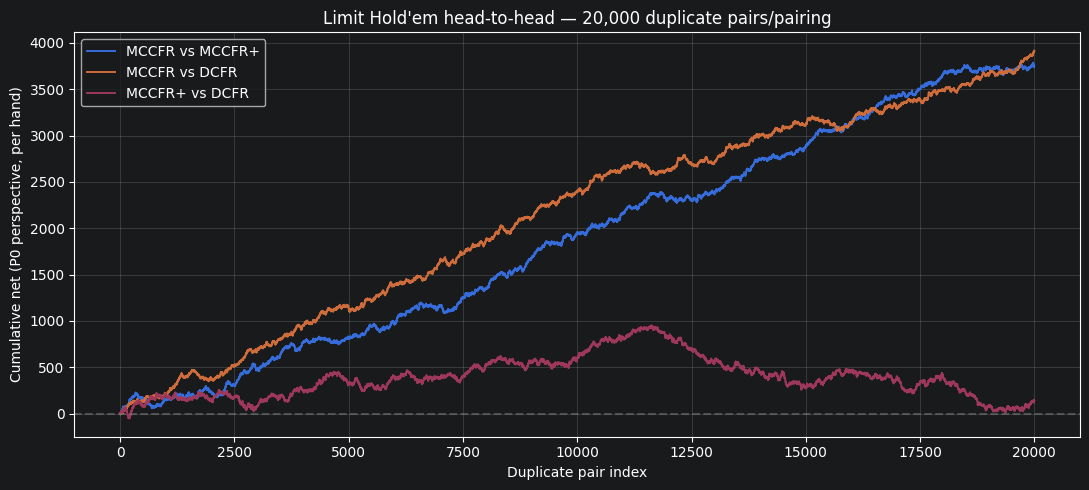

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
for (a, b), r in results.items():
    ax.plot(np.cumsum(r['nets']) / 2.0, linewidth=1.4, label=f'{a} vs {b}')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Duplicate pair index')
ax.set_ylabel('Cumulative net (P0 perspective, per hand)')
ax.set_title(f'Limit Hold\'em head-to-head — {NUM_MATCH_PAIRS:,} duplicate pairs/pairing')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Overall ranking

In [9]:
scores = []
for a in names:
    row = [matrix[a][b] for b in names]
    avg = sum(row) / (len(names) - 1)
    scores.append((a, avg))
scores.sort(key=lambda x: -x[1])

print('Ranking (avg net per hand across opponents):')
for i, (name, avg) in enumerate(scores, 1):
    print(f'  {i}. {name:<8} {avg:+.4f}')

Ranking (avg net per hand across opponents):
  1. MCCFR    +0.1917
  2. MCCFR+   -0.0903
  3. DCFR     -0.1014
